# **Milestone 02: Data Preparation, EDA and Hypothesis Report**
## Commodity price shocks as an early-warning signal for US initial jobless claims

**Course:** Data Science for Social Good  
**Team:** Rana Mohammad Sarib Khan (rk09083, Social Development & Policy, CS minor) · Abdullah Ahmed (aa09303, Computer Engineering) · Hassan Shahzad (ms09070, Computer Science)  
**SDG:** 8 – Decent Work and Economic Growth, Target 8.5

This notebook is the executable companion to the Milestone 02 PDF (Draft Sections II and III of the manuscript).
Every table and figure in the PDF is produced here and written to `data/processed/tables/` and `figures/`.
The data pipeline lives in `src/collect.py` (raw pulls) and `src/build_master.py` (weekly master dataset) and is
imported below so the notebook and the scripts can never disagree.

In [1]:
import sys, json, inspect, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from build_master import (build_master, data_dictionary, weekly_from_daily, add_commodity_features, add_lags,
                          load_daily, load_icsa, COMMODITIES, MAX_LAG, COVID, spike_threshold)

TABLES = ROOT / "data" / "processed" / "tables"; TABLES.mkdir(parents=True, exist_ok=True)
FIGS = ROOT / "figures"; FIGS.mkdir(exist_ok=True)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 3)

# --- plotting conventions used for every figure ---------------------------------------
# Fixed categorical hue per commodity (never re-assigned between figures); claims in near-black ink;
# recessions in neutral gray. Palette validated for colour-vision deficiency (adjacent-pair ΔE ≥ 8).
COLORS = {"oil": "#2a78d6", "gas": "#eb6834", "copper": "#1baf7a", "iron": "#eda100",
          "claims": "#0b0b0b", "rec": "#d9d8d3", "muted": "#52514e"}
LABELS = {"oil": "WTI crude oil", "gas": "Henry Hub natural gas", "copper": "Copper (COMEX)", "iron": "Iron ore 62% Fe"}
UNITS  = {k: v[2] for k, v in COMMODITIES.items()}
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 10, "axes.titlesize": 11,
                     "axes.titleweight": "semibold", "axes.labelsize": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e1",
                     "grid.linewidth": 0.6, "axes.edgecolor": "#b5b4ae", "legend.frameon": False})
KEYS = list(COMMODITIES)
print("pandas", pd.__version__, "| project root:", ROOT)

pandas 3.0.6 | project root: /Users/hassan/DS_project


# **Section 1: Project Alignment & Master Dataset Inventory**

## 1.1 Team metadata and problem summary

| Member | ID | Disciplinary background |
|---|---|---|
| Rana Mohammad Sarib Khan | rk09083 | Social Development & Policy, CS minor |
| Abdullah Ahmed | aa09303 | Computer Engineering |
| Hassan Shahzad | ms09070 | Computer Science |

**Project title.** *Commodity Price Shocks as an Early-Warning Signal for US Initial Jobless Claims.*

**Primary social research question.** Do sudden changes (and volatility) in the prices of core energy
(crude oil, natural gas) and industrial-metal (copper, iron ore) commodities predict increases in US weekly
initial unemployment-insurance claims, and with what lag? An answer lets policymakers pre-position safety-net
resources before official labour statistics confirm a layoff wave (SDG 8.5, full and productive employment).

## 1.2 Master dataset overview
The master dataset is built by `src/build_master.py`. Running it here rebuilds it from the cached raw files.

In [2]:
master = build_master()
master.to_csv(ROOT / "data" / "processed" / "master_weekly.csv", float_format="%.6f")
manifest = json.loads((ROOT / "data" / "raw" / "manifest.json").read_text())

overview = pd.DataFrame({
    "Item": ["Observations (rows)", "Variables (columns)", "Observational unit", "Time span",
             "Target variable", "Commodity predictors", "Controls / dummies", "Raw sources"],
    "Value": [f"{master.shape[0]:,} weeks", f"{master.shape[1]}",
              "1 row = 1 calendar week ending Saturday (the US Department of Labor's 'week ending' convention for initial claims)",
              f"{master.index.min().date()} to {master.index.max().date()}",
              "icsa (weekly initial claims, persons) and its derived log / % change / spike indicator",
              "4 commodities × (base weekly mean price, weekly % price shock, 4-week volatility); lags 1–16 of the shock are created on demand by add_lags()",
              "NBER recession (usrec), COVID period (covid_period)",
              "FRED API (6 series), Yahoo Finance via yfinance (2 futures tickers)"]})
overview.to_csv(TABLES / "t01_master_overview.csv", index=False)
display(overview.style.hide(axis="index").set_properties(**{"text-align": "left"}))

sources = (pd.DataFrame(manifest).T
           .loc[:, ["description", "frequency", "rows", "first_date", "last_date", "source"]]
           .rename_axis("series").reset_index())
sources.to_csv(TABLES / "t02_sources.csv", index=False)
display(sources.drop(columns="source"))

Item,Value
Observations (rows),"1,500 weeks"
Variables (columns),17
Observational unit,1 row = 1 calendar week ending Saturday (the US Department of Labor's 'week ending' convention for initial claims)
Time span,1998-01-03 to 2026-09-26
Target variable,"icsa (weekly initial claims, persons) and its derived log / % change / spike indicator"
Commodity predictors,"4 commodities × (base weekly mean price, weekly % price shock, 4-week volatility); lags 1–16 of the shock are created on demand by add_lags()"
Controls / dummies,"NBER recession (usrec), COVID period (covid_period)"
Raw sources,"FRED API (6 series), Yahoo Finance via yfinance (2 futures tickers)"


,series,description,frequency,rows,first_date,last_date
0,ICSA,"Initial Claims (weekly, SA, persons)",weekly,1500,1998-01-03,2026-09-26
1,DCOILWTICO,"WTI crude oil spot (daily, USD/bbl)",daily,7499,1998-01-01,2026-09-29
2,DHHNGSP,"Henry Hub natural gas spot (daily, USD/MMBtu)",daily,7499,1998-01-01,2026-09-29
3,USREC,"NBER recession indicator (monthly, 0/1)",monthly,345,1998-01-01,2026-09-01
4,PCOPPUSDM,"Copper global price (monthly, USD/tonne) -- re...",monthly,343,1998-01-01,2026-07-01
5,PIORECRUSDM,"Iron ore global price (monthly, USD/tonne) -- ...",monthly,343,1998-01-01,2026-07-01
6,HG_F,"COMEX copper futures (daily, USD/lb)",daily,6552,2000-08-30,2026-10-02
7,TIO_F,"Iron ore 62% Fe CFR China futures (daily, USD/...",daily,4003,2010-10-14,2026-10-02


### Interpretation
The master table has **1,500 weekly observations and 17 variables**, covering every week from 3 January 1998 to
the latest published claims week. The unit of observation is the Department of Labor's reference week (Sunday to
Saturday), so the target is never resampled; every other series is brought *to* that grid. Eight raw files feed
the table: six FRED series (claims, two daily spot prices, the monthly NBER recession flag, and the two monthly
metal benchmarks kept for reference) and two daily futures series from Yahoo Finance for the metals, following the
Milestone 01 source-selection test. The 17 columns are exactly the proposal's feature families: the claims target (level, log, weekly change), and per
commodity the base weekly price, the weekly percentage price shock and the 4-week volatility, plus two regime flags.
The proposal's exploratory 16-week lag block (4 commodities × 16 lags = 64 columns) is deliberately **not stored**:
`add_lags()` in `build_master.py` creates it on demand, and the modelling stage will keep only the strongest lags per commodity.

# **Section 2: Data Ingestion, Cleaning & Structural Readiness**

## 2.1 Scraping / collection audit
`src/collect.py` pulls every series programmatically and records provenance in `data/raw/manifest.json`.

* **FRED.** Each series is fetched from the keyless CSV endpoint
  `https://fred.stlouisfed.org/graph/fredgraph.csv?id=<SERIES>`. FRED writes a `.` for days with no observation
  (holidays, market closures); these are parsed to `NaN` at load time. One practical finding: FRED stalls on
  browser-style `User-Agent` strings sent without full browser headers, so the request is made with the default
  `python-requests` agent.
* **Yahoo Finance.** `yfinance.download(ticker, start="1998-01-01", interval="1d")` for `HG=F` (COMEX copper,
  USD/lb) and `TIO=F` (iron ore 62% Fe CFR China, USD/tonne). A fallback hits the chart endpoint directly with explicit
  `period1`/`period2` timestamps, because `range=max` silently downgrades the response to monthly bars.
* **Coverage check.** Querying `TIO=F` for 2007–2010 returns `{"error": {"code": "Bad Request",
  "description": "Data doesn't exist for startDate = 1167591600, endDate = 1285873200"}}`: the contract was listed on
  14 October 2010, so iron ore is **structurally missing** before then. Likewise copper futures begin on 30 August
  2000. These gaps are kept as `NaN` rather than back-filled (see 2.3).

In [3]:
# First rows of each raw file, exactly as cached -- the audit trail for the collection step
for name, meta in manifest.items():
    df = pd.read_csv(ROOT / meta["file"], nrows=2)
    print(f"{name:<12} {meta['frequency']:<8} {meta['rows']:>5} rows  {meta['first_date']} -> {meta['last_date']}   "
          f"pulled {meta['pulled_at_utc']}")
    print("   ", df.to_dict("records")[0])

ICSA         weekly    1500 rows  1998-01-03 -> 2026-09-26   pulled 2026-10-04 10:48 UTC
    {'date': '1998-01-03', 'value': 312000}
DCOILWTICO   daily     7499 rows  1998-01-01 -> 2026-09-29   pulled 2026-10-04 10:48 UTC
    {'date': '1998-01-01', 'value': nan}
DHHNGSP      daily     7499 rows  1998-01-01 -> 2026-09-29   pulled 2026-10-04 10:48 UTC
    {'date': '1998-01-01', 'value': nan}
USREC        monthly    345 rows  1998-01-01 -> 2026-09-01   pulled 2026-10-04 10:48 UTC
    {'date': '1998-01-01', 'value': 0}
PCOPPUSDM    monthly    343 rows  1998-01-01 -> 2026-07-01   pulled 2026-10-04 10:48 UTC
    {'date': '1998-01-01', 'value': 1687.60000986328}
PIORECRUSDM  monthly    343 rows  1998-01-01 -> 2026-07-01   pulled 2026-10-04 10:48 UTC
    {'date': '1998-01-01', 'value': 13.41}
HG_F         daily     6552 rows  2000-08-30 -> 2026-10-02   pulled 2026-10-04 10:48 UTC
    {'date': '2000-08-30', 'open': 0.8790000081062317, 'high': 0.8870000243186951, 'low': 0.8769999742507935, 'clos

## 2.2 Data alignment and structural organisation
The raw files arrive at three frequencies (weekly, daily, monthly) and two different week conventions.
The reshaping below produces one modelling-ready table keyed on the claims reference week:

1. **Daily → weekly (down-sampling).** Each daily price series is grouped into Sunday–Saturday bins labelled by
   the Saturday (`resample("W-SAT")`). Per week we keep the *mean* price (the base weekly price) and a trailing
   20-trading-day volatility of daily log returns sampled on the last day of the week; weeks with no trading day at
   all are set to missing.
2. **Monthly → weekly (up-sampling).** The NBER recession flag is forward-filled from the month start to every week
   in that month.
3. **Join.** All weekly frames are left-joined onto the claims index, so the claims weeks define the sample and
   no commodity week without a claims observation enters the table.
4. **Feature construction.** Week-over-week percentage change of the weekly mean (the price shock). Lags 1–16 of
   the shock, the proposal's exploratory window, are produced on demand by `add_lags()` rather than stored.

The functions that do this are printed below from `src/build_master.py`.

In [4]:
print(inspect.getsource(weekly_from_daily))
print(inspect.getsource(add_commodity_features))
print(inspect.getsource(add_lags))

def weekly_from_daily(daily: pd.Series, key: str) -> pd.DataFrame:
    """Collapse a daily price series to Sunday-Saturday weeks (label = Saturday).

    Returns, per week:
        {key}_mean    mean of daily prices in the week      (base weekly price)
        {key}_vol_4w  std of daily log returns over the trailing 20 trading days,
                      taken at the last day of the week      (4-week rolling volatility)
    Weeks with no trading day at all (exchange closures) are set to NaN.
    """
    # WTI printed a negative settlement on 2020-04-20 (-37.63 USD/bbl); the log
    # return is undefined there, so that single day is excluded from the
    # return-based volatility feature only. Price levels keep the true value.
    logret = np.log(daily.where(daily > 0)).diff()
    vol20 = logret.rolling(20, min_periods=10).std()
    wk = pd.DataFrame({
        f"{key}_mean":   daily.resample("W-SAT").mean(),
        f"{key}_vol_4w": vol20.resample("W-SAT").last(),
    })
    n_days = da

In [5]:
# Worked example of the daily -> weekly collapse for one week, so the aggregation is auditable.
# The week ending 2020-04-25 contains the only negative WTI settlement in history (2020-04-20).
oil_daily = load_daily("oil")
example_week = oil_daily["2020-04-19":"2020-04-25"]
print("Daily WTI prices, week ending 2020-04-25 (USD/barrel):")
print(example_week.to_string())
print("\nWeekly row produced for that week:")
display(master.loc[["2020-04-25"], ["oil_mean", "oil_pct_1w", "oil_vol_4w"]])

# Alignment check: every master index date is a Saturday and spacing is exactly 7 days
print("All Saturdays:", (master.index.dayofweek == 5).all(),
      "| unique 7-day spacing:", master.index.to_series().diff().dropna().unique())

Daily WTI prices, week ending 2020-04-25 (USD/barrel):
date
2020-04-20   -36.98
2020-04-21     8.91
2020-04-22    13.64
2020-04-23    15.06
2020-04-24    15.99

Weekly row produced for that week:


,oil_mean,oil_pct_1w,oil_vol_4w
week_ending,,,
2020-04-25,3.324,-83.479,0.159


All Saturdays: True | unique 7-day spacing: <TimedeltaArray>
['7 days']
Length: 1, dtype: timedelta64[us]


### Interpretation
The worked example shows the collapse from five trading days to a single row and makes the choice of
*mean* rather than *close* visible: the week of 25 April 2020 closes at 15.99 USD/bbl, but its mean is 3.32 USD/bbl
because of the −37.63 USD/bbl print on 20 April. The weekly mean is the stored level feature because it is what a
business paying for inputs over the week actually faced; the close is not kept. The log return
on the negative day is undefined, so that single observation is excluded from the return-based volatility
features only, never from the price level. The index passes both structural checks (all Saturdays, uniform 7-day spacing).

## 2.3 Cleaning and missing-data strategy

In [6]:
miss = pd.DataFrame({"missing_n": master.isna().sum(), "missing_pct": master.isna().mean() * 100})
miss["missing_pct"] = miss["missing_pct"].round(2)
miss.to_csv(TABLES / "t03_missing_all_columns.csv")
display(miss.T)

# where is the missingness in time?  share of weeks per year with a missing weekly mean
by_year = (master[[f"{k}_mean" for k in KEYS]].isna()
           .groupby(master.index.year).mean().mul(100).round(0).astype(int))
by_year.columns = KEYS
by_year.index.name = "year"
by_year.to_csv(TABLES / "t04_missing_by_year.csv")
display(by_year.T)

,icsa,log_icsa,icsa_pct_chg_1w,oil_mean,oil_pct_1w,oil_vol_4w,gas_mean,gas_pct_1w,gas_vol_4w,copper_mean,copper_pct_1w,copper_vol_4w,iron_mean,iron_pct_1w,iron_vol_4w,usrec,covid_period
missing_n,0.0,0.0,1.00,4.00,8.00,6.0,121.00,203.00,126.0,139.00,140.00,141.0,667.00,668.00,669.0,0.0,0.0
missing_pct,0.0,0.0,0.07,0.27,0.53,0.4,8.07,13.53,8.4,9.27,9.33,9.4,44.47,44.53,44.6,0.0,0.0


year,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
oil,2,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
gas,17,25,13,12,29,37,35,21,31,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
copper,100,100,66,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
iron,100,100,100,100,100,100,100,100,100,100,100,100,79,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Missing-data findings and handling rationale

| Variable group | Missing | Mechanism | Decision |
|---|---|---|---|
| `icsa` and all target columns | 0 % (1 % for the first-difference, by construction) | — | Never imputed. |
| `oil_*` | 0.3 % (4 weeks in 1998–99) | Sparse early FRED daily coverage | Left `NaN`. |
| `gas_*` | 8.1 % (121 weeks, all before April 2007) | FRED's Henry Hub daily series is intermittent before 2007 (roughly one trading day in four is recorded) | Left `NaN`; documented as source sparsity. |
| `copper_*` | 9.3 % (all weeks before 2000-09-02) | **Structural:** COMEX copper futures history on Yahoo begins 30 Aug 2000 | Left `NaN`. |
| `iron_*` | 44.5 % (all weeks before 2010-10-16) | **Structural:** TIO=F listed 14 Oct 2010; the API returns "Data doesn't exist" for earlier dates | Left `NaN`. |
| `*_vol_4w` | a few extra weeks per commodity | The 20-day rolling window needs ≥ 10 returns | Left `NaN`. |
| `usrec`, `covid_period` | 0 % | — | — |

**Why no imputation.** Mean/median imputation of a price level that did not exist would inject a constant into a
time series and destroy the very week-to-week variation the project studies; time-series interpolation across a
*ten-year* hole (iron ore) would be fabrication, not estimation. Back-filling iron ore from FRED's monthly benchmark
was considered and rejected on two grounds: (i) before 2010 iron ore was priced on *annual* contracts, so the FRED
series is a flat step function (36.63 USD/t for all of 2007) carrying no weekly information, and (ii) mixing two
sources in one column contradicts the single-source decision made in Milestone 01. The target is complete, so no
rows are dropped from the master table; instead, each model will use **listwise deletion on the columns it actually
uses**. A model with copper will therefore train on 2000–2026 (1,361 weeks) and a model with iron ore on 2010–2026
(833 weeks).

**Selection bias.** Listwise deletion is harmless only if missingness is unrelated to the outcome. Here it is
related to *time*, which is in turn related to the outcome: any specification that includes iron ore sees neither
the 2001 recession nor the 2008–09 financial crisis, the two largest claims episodes other than COVID-19. Such a
model would be estimated on a sample with a narrower range of labour-market stress and could understate effects
that only materialise in deep recessions. We flag this explicitly and plan to report metal-based models both with
and without iron ore. The pre-2007 gas sparsity has the opposite character: missing weeks are scattered across
ordinary years, so their omission is closer to random.

## 2.4 Transformations and encoding

In [7]:
# --- Feature rescaling: log transform for heavy right skew ---------------------------------
skew_tbl = pd.DataFrame({
    "variable": ["icsa"] + [f"{k}_mean" for k in KEYS],
    "skew (raw)": [stats.skew(master["icsa"])] + [stats.skew(master[f"{k}_mean"].dropna()) for k in KEYS],
    "skew (log)": [stats.skew(master["log_icsa"])] + [stats.skew(np.log(master[f"{k}_mean"].dropna())) for k in KEYS],
}).round(2)
skew_tbl.to_csv(TABLES / "t05_log_transform_skew.csv", index=False)
display(skew_tbl)

,variable,skew (raw),skew (log)
0,icsa,11.22,2.30
1,oil_mean,0.11,-0.90
2,gas_mean,1.75,0.55
3,copper_mean,0.01,-1.08
4,iron_mean,0.47,-0.34


### Interpretation: log transformation
Initial claims are extremely right-skewed (skewness 11.2): only 50 of 1,500 weeks exceed 700,000, but the
pandemic weeks reach 6.1 million. `log_icsa` reduces skewness to 2.3 and is the response scale we intend to model;
a one-unit change in log claims is a constant *percentage* change, which is also how policymakers talk about
layoff waves. Natural gas is the only commodity with material right skew (1.75, driven by the 2005 and 2022 spikes),
and the log reduces it to 0.55. Crude oil, copper and iron ore are already close to symmetric in levels (0.11,
0.01, 0.47) and the log *over*-corrects oil and copper into moderate left skew (−0.9, −1.1), so for the commodities
the raw level is what the master stores; a log can be applied at model time if an elasticity specification is wanted.

In [8]:
# --- Scaling: z-score standardisation and Min-Max normalisation -------------------------
scale_cols = ["icsa", "log_icsa", "oil_mean", "gas_mean", "copper_mean", "iron_mean"]
raw = master[scale_cols]
z_scored = (raw - raw.mean()) / raw.std(ddof=1)                 # standardisation: mean 0, sd 1
min_max = (raw - raw.min()) / (raw.max() - raw.min())            # normalisation: range [0, 1]
scale_demo = pd.concat({
    "raw":    raw.describe().loc[["mean", "std", "min", "max"]],
    "z":      z_scored.describe().loc[["mean", "std", "min", "max"]],
    "minmax": min_max.describe().loc[["mean", "std", "min", "max"]],
}, axis=0).round(3)
scale_demo.to_csv(TABLES / "t06_scaling_summary.csv")
display(scale_demo)

icsa  log_icsa  oil_mean  gas_mean  copper_mean  iron_mean
raw    mean  3.616e+05    12.689    61.120     4.061     6462.296    106.807
       std   3.307e+05     0.382    26.925     2.152     2823.633     36.174
       min   1.890e+05    12.150     3.324     1.400     1359.148     38.730
       max   6.137e+06    15.630   142.518    14.820    14787.709    218.396
z      mean -0.000e+00    -0.000    -0.000    -0.000       -0.000     -0.000
       std   1.000e+00     1.000     1.000     1.000        1.000      1.000
       min  -5.220e-01    -1.413    -2.147    -1.237       -1.807     -1.882
       max   1.747e+01     7.708     3.023     5.000        2.948      3.085
minmax mean  2.900e-02     0.155     0.415     0.198        0.380      0.379
       std   5.600e-02     0.110     0.193     0.160        0.210      0.201
       min   0.000e+00     0.000     0.000     0.000        0.000      0.000
       max   1.000e+00     1.000     1.000     1.000        1.000      1.000

### Interpretation: scaling
Both scalings are computed here and deliberately **not stored** in the master. Standardisation is the default for the
regression-type models planned (coefficients become comparable across commodities measured in dollars per barrel,
per MMBtu and per tonne); Min-Max normalisation serves bounded-input models. Because the min, max, mean and standard
deviation above are **full-sample** statistics, writing the scaled columns to disk would bake look-ahead information
into the file; in Milestone 03 the scalers are fitted on the training window inside the model pipeline.

In [9]:
# --- Categorical encoding: nominal strings -> Boolean dummy indicator flags ----------------
# Two nominal variables are constructed from the data and encoded with pandas.get_dummies:
nominal = pd.DataFrame({
    "quarter": "Q" + master.index.quarter.astype(str),
    "regime":  np.where(master["usrec"] == 1, "recession", "expansion"),
}, index=master.index)
print("Nominal string columns (first 3 rows):"); display(nominal.head(3))

dummies = pd.get_dummies(nominal, prefix=["q", "regime"], drop_first=True, dtype=int)  # reference: Q1, expansion
print("\nAfter get_dummies(drop_first=True) -> one Boolean 0/1 flag per non-reference level:")
display(dummies.head(3))

# The master's usrec column is exactly this regime dummy; verify
assert (dummies["regime_recession"].to_numpy() == master["usrec"].to_numpy()).all()

dummy_counts = master[["usrec", "covid_period"]].agg(["sum", "mean"]).T
dummy_counts.columns = ["weeks = 1", "share"]
dummy_counts["share"] = dummy_counts["share"].round(3)
dummy_counts.to_csv(TABLES / "t07_dummy_counts.csv")
display(dummy_counts)

Nominal string columns (first 3 rows):


,quarter,regime
week_ending,,
1998-01-03,Q1,expansion
1998-01-10,Q1,expansion
1998-01-17,Q1,expansion



After get_dummies(drop_first=True) -> one Boolean 0/1 flag per non-reference level:


,q_Q2,q_Q3,q_Q4,regime_recession
week_ending,,,,
1998-01-03,0,0,0,0
1998-01-10,0,0,0,0
1998-01-17,0,0,0,0


,weeks = 1,share
usrec,120.0,0.080
covid_period,43.0,0.029


### Interpretation: dummy encoding
`get_dummies(drop_first=True)` converts the two nominal strings into four 0/1 indicators (`Q2`, `Q3`, `Q4`,
`recession`); Q1 and expansion are the reference levels, which avoids the dummy-variable trap in a regression with
an intercept. Only the regime dummy is kept in the master, as `usrec` (the assertion confirms the two are identical).
The quarter dummies are shown for the encoding mechanics but not stored, because initial claims are published
seasonally adjusted and a quarter effect would be double-counting. The other stored flag is `covid_period`
(43 weeks), which the proposal anticipates needing to isolate the pandemic layoffs. Only 120 weeks (8 %) fall inside
an NBER recession, which already warns that any regime-interaction hypothesis will rest on a small number of
recession observations.

# **Section 3: Exploratory Data Analysis & Initial Findings**

## 3.1 Univariate summary statistics

In [10]:
# Analysis-only column (not part of the stored master): a 'claims spike' week is a top-decile weekly rise
master["icsa_spike"] = (master["icsa_pct_chg_1w"] >= spike_threshold(master)).astype(int)

def univariate(s: pd.Series) -> pd.Series:
    s = s.dropna(); q1, q3 = s.quantile([0.25, 0.75])
    return pd.Series({"n": len(s), "mean": s.mean(), "median": s.median(), "SD": s.std(ddof=1), "IQR": q3 - q1,
                      "min": s.min(), "max": s.max(), "skewness": stats.skew(s)})

uni_cols = (["icsa", "icsa_pct_chg_1w"] + [f"{k}_mean" for k in KEYS]
            + [f"{k}_pct_1w" for k in KEYS] + [f"{k}_vol_4w" for k in KEYS])
uni = master[uni_cols].apply(univariate).T
uni.insert(0, "unit", ["persons/wk", "%"] + [UNITS[k] for k in KEYS] + ["%"] * 4 + ["log-ret SD"] * 4)
uni["n"] = uni["n"].astype(int)
uni.to_csv(TABLES / "t08_univariate.csv")
display(uni.round(3))

,unit,n,mean,median,SD,IQR,min,max,skewness
icsa,persons/wk,1500,361644.667,315000.000,330652.025,146000.000,189000.000,6.137e+06,11.221
icsa_pct_chg_1w,%,1499,0.585,-0.311,25.556,5.150,-20.662,9.674e+02,36.202
oil_mean,USD/barrel,1496,61.120,61.342,26.925,41.165,3.324,1.425e+02,0.114
gas_mean,USD/MMBtu,1379,4.061,3.304,2.152,2.142,1.400,1.482e+01,1.755
copper_mean,USD/tonne,1361,6462.296,6763.774,2823.633,3501.818,1359.148,1.479e+04,0.014
iron_mean,USD/tonne,833,106.807,104.718,36.174,50.624,38.730,2.184e+02,0.474
oil_pct_1w,%,1492,0.424,0.438,10.988,5.182,-83.479,3.727e+02,25.820
gas_pct_1w,%,1297,0.792,-0.090,14.219,8.494,-76.542,3.006e+02,9.176
copper_pct_1w,%,1360,0.191,0.161,2.887,3.210,-15.955,1.039e+01,-0.301
iron_pct_1w,%,832,0.016,0.083,3.595,2.622,-19.627,1.783e+01,-0.501


In [11]:
# Resistant vs non-resistant measures: how much do the mean/SD move if the 44 COVID weeks are removed?
covid_mask = (master.index >= COVID[0]) & (master.index <= COVID[1])
resist = pd.DataFrame({
    "all weeks":        univariate(master["icsa"]),
    "excluding Mar-Dec 2020": univariate(master.loc[~covid_mask, "icsa"]),   # 43 weeks removed
}).loc[["n", "mean", "median", "SD", "IQR"]]
resist["% change"] = ((resist.iloc[:, 1] / resist.iloc[:, 0] - 1) * 100).round(1)
resist.to_csv(TABLES / "t09_resistant_vs_nonresistant.csv")
display(resist.round(1))

,all weeks,excluding Mar-Dec 2020,% change
n,1500.0,1457.0,-2.9
mean,361644.7,325163.3,-10.1
median,315000.0,313000.0,-0.6
SD,330652.0,100782.9,-69.5
IQR,146000.0,139000.0,-4.8


### Interpretation
**Claims.** Mean weekly claims (362,000) sit 15 % above the median (315,000) and the SD (331,000) is 2.3 times the
IQR (146,000), the signature of a heavy right tail. Removing the 43 pandemic weeks cuts the mean by 10 % and the SD by
70 % but moves the median by under 1 % and the IQR by 5 %: the median and IQR are *resistant*, the mean and SD are not.
We therefore report medians and IQRs as the headline descriptives and use the log scale in models.

**Commodities.** Crude oil averages 61 USD/bbl with an almost symmetric distribution (skew 0.1); copper averages
6,460 USD/t; iron ore 107 USD/t. Natural gas (mean 4.06 vs median 3.30 USD/MMBtu) is right-skewed. The weekly
*percentage changes* are centred near zero, as expected for prices, but their tails differ sharply: oil and gas
have week-over-week moves of −83 % / +373 % and −77 % / +301 % (the April 2020 oil collapse and the 2005/2022 gas
squeezes), whereas copper and iron ore never move more than ±20 % in a week. Copper is the least volatile input in
this sample.

## 3.2 Outlier diagnostic: z-score rule vs quartile (IQR) rule

In [12]:
def outlier_audit(s: pd.Series) -> dict:
    s = s.dropna()
    z = (s - s.mean()) / s.std(ddof=1)
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return {"n": len(s), "z-rule |z|>3 (count)": int((z.abs() > 3).sum()),
            "z upper bound": s.mean() + 3 * s.std(ddof=1),
            "IQR-rule (count)": int(((s < lo) | (s > hi)).sum()), "IQR upper bound": hi,
            "max": s.max()}

audit_cols = ["icsa", "icsa_pct_chg_1w"] + [f"{k}_pct_1w" for k in KEYS]
audit_all = pd.DataFrame({c: outlier_audit(master[c]) for c in audit_cols}).T
audit_excl = pd.DataFrame({c: outlier_audit(master.loc[~covid_mask, c]) for c in audit_cols}).T
audit = pd.concat({"full sample": audit_all, "excluding Mar-Dec 2020": audit_excl}, axis=1)
audit.to_csv(TABLES / "t10_outlier_audit.csv")
display(audit_all.round(1)); display(audit_excl.round(1))

,n,z-rule |z|>3 (count),z upper bound,IQR-rule (count),IQR upper bound,max
icsa,1500.0,18.0,1.354e+06,71.0,606000.0,6.137e+06
icsa_pct_chg_1w,1499.0,2.0,7.730e+01,51.0,10.2,9.674e+02
oil_pct_1w,1492.0,3.0,3.340e+01,55.0,10.6,3.727e+02
gas_pct_1w,1297.0,14.0,4.340e+01,78.0,17.0,3.006e+02
copper_pct_1w,1360.0,17.0,8.900e+00,52.0,6.7,1.040e+01
iron_pct_1w,832.0,17.0,1.080e+01,88.0,5.4,1.780e+01


,n,z-rule |z|>3 (count),z upper bound,IQR-rule (count),IQR upper bound,max
icsa,1457.0,24.0,627512.2,37.0,587500.0,890000.0
icsa_pct_chg_1w,1456.0,18.0,13.1,42.0,10.0,29.4
oil_pct_1w,1449.0,17.0,13.4,43.0,10.6,28.6
gas_pct_1w,1254.0,13.0,43.9,77.0,16.8,300.6
copper_pct_1w,1317.0,15.0,8.9,50.0,6.6,10.4
iron_pct_1w,789.0,18.0,10.8,86.0,5.3,17.8


### Interpretation: masking and variance inflation
The two rules disagree by an order of magnitude. On weekly claims the z-score rule flags **18** weeks, the IQR rule
**71**; on the weekly % change in claims the z-rule flags **2** weeks against **51** for the IQR rule. The reason is
*variance inflation*: the pandemic weeks push the SD of claims from 101,000 to 331,000, so the z-rule's upper
bound climbs to 1.35 million and everything short of the COVID spike is hidden behind it. This is the **masking
effect**: the most extreme outliers inflate the very scale used to detect outliers, concealing the 2008–09 peak
(665,000) and every other recession week. The IQR rule, whose bound (606,000) depends only on the middle half of the
data, is unaffected and isolates exactly the recession periods. Dropping the 43 pandemic weeks and re-running the
z-rule raises its count to 24, confirming that those weeks had been masking others.

These extreme weeks are *real* events, not errors, so they are **retained**. Their influence is controlled
instead through (i) the log transform of the target, (ii) the `covid_period` dummy, which lets a model absorb the
pandemic level shift, and (iii) robust loss functions where appropriate. For the commodity shocks the same pattern
holds: the −83 % / +373 % oil weeks of April–May 2020 alone move the SD of `oil_pct_1w` from 4.4 to 11.0 percentage
points, so the z-rule finds only 3 outliers where the IQR rule finds 55.

## 3.3 Bivariate and multivariate exploration

In [13]:
# (a) Correlation matrix of the key continuous variables (log levels, weekly % changes, volatility, regime)
log_levels = np.log(master[[f"{k}_mean" for k in KEYS]]).rename(columns=lambda c: c.replace("_mean", "_log_mean"))
corr_df = pd.concat([master[["log_icsa", "icsa_pct_chg_1w"]], log_levels,
                     master[[f"{k}_pct_1w" for k in KEYS] + [f"{k}_vol_4w" for k in KEYS] + ["usrec"]]], axis=1)
corr = corr_df.corr(method="pearson")
corr.to_csv(TABLES / "t11_correlation_matrix.csv")
display(corr.round(2))

,log_icsa,icsa_pct_chg_1w,oil_log_mean,gas_log_mean,copper_log_mean,iron_log_mean,oil_pct_1w,gas_pct_1w,copper_pct_1w,iron_pct_1w,oil_vol_4w,gas_vol_4w,copper_vol_4w,iron_vol_4w,usrec
log_icsa,1.00,0.15,-0.20,0.03,-0.28,0.29,0.12,0.01,0.04,0.05,0.43,-0.01,0.17,-0.02,0.34
icsa_pct_chg_1w,0.15,1.00,-0.04,-0.04,-0.01,-0.02,-0.08,-0.02,-0.10,0.00,0.16,-0.00,0.02,-0.02,0.10
oil_log_mean,-0.20,-0.04,1.00,0.34,0.82,0.59,-0.02,-0.01,-0.03,-0.07,-0.41,-0.19,0.09,-0.12,-0.03
gas_log_mean,0.03,-0.04,0.34,1.00,-0.12,0.29,-0.03,0.15,-0.00,-0.08,-0.11,0.10,0.28,0.02,0.22
copper_log_mean,-0.28,-0.01,0.82,-0.12,1.00,0.64,0.00,0.02,0.02,-0.00,-0.24,-0.12,0.10,-0.19,-0.21
iron_log_mean,0.29,-0.02,0.59,0.29,0.64,1.00,0.00,0.04,0.01,0.04,-0.15,0.10,0.14,-0.18,-0.04
oil_pct_1w,0.12,-0.08,-0.02,-0.03,0.00,0.00,1.00,0.01,0.15,0.03,0.16,0.01,-0.02,-0.03,-0.06
gas_pct_1w,0.01,-0.02,-0.01,0.15,0.02,0.04,0.01,1.00,0.04,0.01,-0.03,0.11,-0.01,-0.01,-0.04
copper_pct_1w,0.04,-0.10,-0.03,-0.00,0.02,0.01,0.15,0.04,1.00,0.23,-0.03,0.05,-0.08,0.04,-0.06
iron_pct_1w,0.05,0.00,-0.07,-0.08,-0.00,0.04,0.03,0.01,0.23,1.00,0.00,0.00,-0.05,-0.13,-0.01


In [14]:
# (b) Cross-correlation of each commodity's weekly % change with the % change in claims, lags 0..16.
#     A positive lag k means the commodity move happened k weeks BEFORE the claims move.
y = master["icsa_pct_chg_1w"]
lagged = add_lags(master)                 # creates {c}_pct_lag1..16 on demand (not stored in the master)
xcorr = pd.DataFrame({k: [y.corr(lagged[f"{k}_pct_1w" if l == 0 else f"{k}_pct_lag{l}"]) for l in range(0, MAX_LAG + 1)] for k in KEYS},
                     index=pd.Index(range(0, MAX_LAG + 1), name="lag (weeks)"))
n_eff = {k: int(pd.concat([y, master[f"{k}_pct_1w"]], axis=1).dropna().shape[0]) for k in KEYS}
band = {k: 2 / np.sqrt(n_eff[k]) for k in KEYS}         # approximate 95 % band for a zero correlation
xcorr.to_csv(TABLES / "t12_cross_correlation_lags.csv")
best = pd.DataFrame({"strongest lag": xcorr.abs().idxmax(), "r at that lag": [xcorr[k][xcorr[k].abs().idxmax()] for k in KEYS],
                     "n": pd.Series(n_eff), "±2/√n band": pd.Series(band)}).round(3)
best.to_csv(TABLES / "t13_xcorr_best_lag.csv")
display(xcorr.round(3).T); display(best)

lag (weeks),0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
oil,-0.082,-0.087,-0.027,-0.032,-0.003,-0.001,-0.014,-0.013,-0.009,-0.012,-0.003,-0.007,-0.006,-0.008,-0.002,0.006,-0.004
gas,-0.016,0.015,-0.010,-0.028,0.007,-0.003,-0.006,-0.003,-0.014,-0.008,0.004,0.001,-0.023,-0.010,-0.009,-0.010,-0.009
copper,-0.097,-0.039,-0.013,-0.017,-0.002,0.006,-0.001,-0.058,-0.047,0.002,0.001,-0.015,0.008,0.017,0.038,-0.006,0.004
iron,0.003,0.007,0.025,0.011,0.031,0.034,-0.133,-0.029,0.002,0.004,0.017,0.009,-0.003,0.005,0.037,0.048,0.015


,strongest lag,r at that lag,n,±2/√n band
oil,1,-0.087,1492,0.052
gas,3,-0.028,1297,0.056
copper,0,-0.097,1360,0.054
iron,6,-0.133,832,0.069


In [15]:
# (c) Group-by aggregation: labour market and commodity behaviour in recession vs expansion weeks
grp_cols = ["icsa", "icsa_pct_chg_1w", "icsa_spike"] + [f"{k}_pct_1w" for k in KEYS] + [f"{k}_vol_4w" for k in KEYS]
regime = master["usrec"].map({0: "expansion", 1: "recession"}).rename("regime")
grp = master.groupby(regime)[grp_cols].agg(["median", "mean"])
grp.to_csv(TABLES / "t14_groupby_regime.csv")
display(grp.T.round(3))
print("weeks per regime:", regime.value_counts().to_dict())

regime                   expansion   recession
icsa            median  309000.000  432500.000
                mean    335130.435  666558.333
icsa_pct_chg_1w median      -0.347       0.260
                mean        -0.187       9.463
icsa_spike      median       0.000       0.000
                mean         0.096       0.142
oil_pct_1w      median       0.478      -0.607
                mean         0.611      -1.705
gas_pct_1w      median      -0.048      -1.034
                mean         0.959      -0.992
copper_pct_1w   median       0.230      -0.390
                mean         0.246      -0.377
iron_pct_1w     median       0.083       0.277
                mean         0.019      -0.340
oil_vol_4w      median       0.021       0.029
                mean         0.023       0.041
gas_vol_4w      median       0.044       0.039
                mean         0.059       0.043
copper_vol_4w   median       0.014       0.020
                mean         0.015       0.023
iron_vol_4w     median       0.011       0.016
                mean         0.014       0.016

weeks per regime: {'expansion': 1380, 'recession': 120}


In [16]:
# (d) Contingency tables: did a large commodity shock 4 weeks earlier precede a claims spike?
#     shock = |weekly % change| in the top decile of that commodity's own distribution
LAG_CT = 4
ct_rows = []
for k in KEYS:
    absmove = master[f"{k}_pct_1w"].abs()
    shock = (absmove >= absmove.quantile(0.90)).astype(float).where(absmove.notna()).shift(LAG_CT)
    tab = pd.crosstab(shock.map({0.0: "no shock", 1.0: "shock"}), master["icsa_spike"].map({0: "no spike", 1: "spike"}))
    chi2, p, dof, _ = stats.chi2_contingency(tab)
    rate_shock = tab.loc["shock", "spike"] / tab.loc["shock"].sum()
    rate_none = tab.loc["no shock", "spike"] / tab.loc["no shock"].sum()
    ct_rows.append({"commodity": LABELS[k], "spike rate after shock": rate_shock, "spike rate otherwise": rate_none,
                    "relative risk": rate_shock / rate_none, "chi2": chi2, "p-value": p})
    print(f"\n{LABELS[k]} shock at t-{LAG_CT}  ×  claims spike at t"); display(tab)
contingency = pd.DataFrame(ct_rows).round(4)
contingency.to_csv(TABLES / "t15_contingency_shock_spike.csv", index=False)
display(contingency)


WTI crude oil shock at t-4  ×  claims spike at t


icsa_spike,no spike,spike
oil_pct_1w,,
no shock,1211,130
shock,128,19



Henry Hub natural gas shock at t-4  ×  claims spike at t

icsa_spike,no spike,spike
gas_pct_1w,,
no shock,1059,104
shock,106,24



Copper (COMEX) shock at t-4  ×  claims spike at t


icsa_spike,no spike,spike
copper_pct_1w,,
no shock,1096,124
shock,124,12



Iron ore 62% Fe shock at t-4  ×  claims spike at t


icsa_spike,no spike,spike
iron_pct_1w,,
no shock,676,68
shock,72,12


,commodity,spike rate after shock,spike rate otherwise,relative risk,chi2,p-value
0,WTI crude oil,0.129,0.097,1.333,1.197,0.274
1,Henry Hub natural gas,0.185,0.089,2.064,10.836,0.001
2,Copper (COMEX),0.088,0.102,0.868,0.118,0.732
3,Iron ore 62% Fe,0.143,0.091,1.563,1.738,0.187


### Interpretation
**Levels.** In log levels, claims correlate *negatively* with oil (−0.20) and copper (−0.28) and *positively*
with iron ore (+0.29) and the recession flag (+0.34). The copper result is the classic "Dr. Copper" pattern: copper is
bought when factories expand, so high copper prices coincide with low unemployment. Oil shows the same demand-side
sign. The iron-ore sign is largely a sample artefact (iron ore exists only from 2010, when claims trended downward
while iron ore first fell then recovered). These level correlations are dominated by shared slow trends and are
**not** evidence about shocks; they mainly tell us that *levels* must enter models with care (detrended, or as
controls).

**Shocks and lags.** Week-over-week changes are, as expected for a noisy weekly series, only weakly cross-correlated
(all |r| < 0.14). The informative part is the *shape* across lags: oil's correlation is most negative at lags 0–1
(an oil price *fall* coincides with claims *rising*, consistent with 2008 and 2020, when demand collapses drove both),
copper peaks at lag 0 and again at lags 7–8, and iron ore has an isolated −0.13 at lag 6. The coefficients that clear
the ±2/√n band are oil at lags 0–1, copper at lags 0 and 7, and iron ore at lag 6; no natural-gas lag clears it. None of these is yet a causal finding, but they tell the
modelling stage where to look and, importantly, warn that the sign may be *negative*: commodity collapses, not only
spikes, precede layoff waves.

**Regimes.** Recession weeks (n = 120) have a median claims level of 432,500 against 309,000 in expansions, a mean
weekly claims change of +9.5 % versus −0.2 %, and 4-week oil volatility about 1.8 times higher on average (0.041 vs 0.023). Commodity *returns* are
lower in recessions for every commodity, again pointing to demand-driven co-movement.

**Contingency.** Conditioning on a top-decile absolute move four weeks earlier, a natural-gas shock is followed by a
claims spike in 18.5 % of weeks versus 8.9 % otherwise (relative risk 2.1, χ² = 10.8, p = 0.001). Oil, copper and
iron ore shocks do not shift the spike rate significantly at this particular lag. The gas result is the strongest
single bivariate signal in the data and feeds directly into hypothesis H2.

## 3.4 Publication-quality visualisations
Conventions: one y-axis per panel; a fixed hue per commodity in every figure (oil blue, gas orange, copper aqua,
iron ore yellow), claims in near-black, NBER recessions as neutral-gray bands; units on every axis; captions below
each figure.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


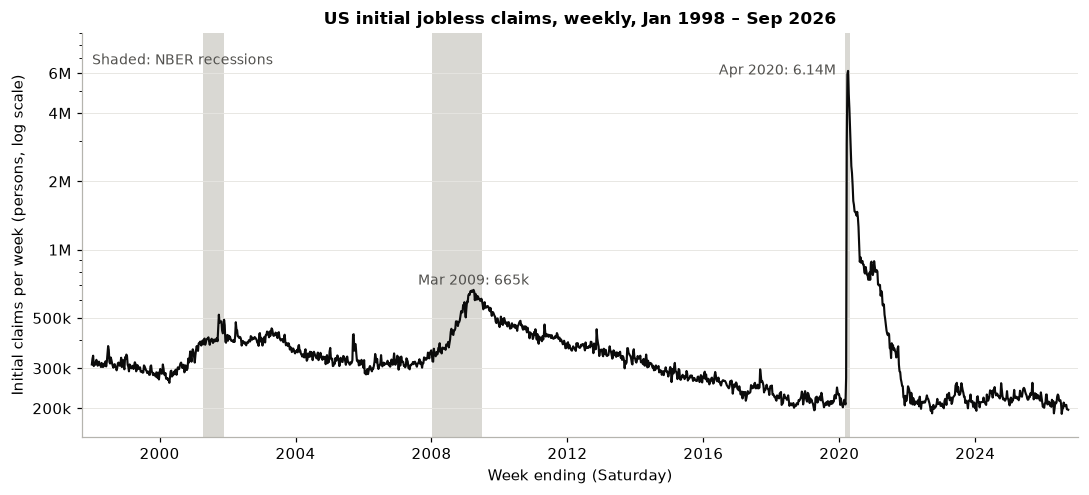

In [17]:
usrec_runs = []           # (start, end) of each recession, for shading
in_rec = master["usrec"].astype(bool)
starts = master.index[in_rec & ~in_rec.shift(1, fill_value=False)]
ends = master.index[in_rec & ~in_rec.shift(-1, fill_value=False)]
usrec_runs = list(zip(starts, ends))

def shade_recessions(ax):
    for s, e in usrec_runs:
        ax.axvspan(s, e, color=COLORS["rec"], zorder=0, lw=0)

# ---- Figure 1: the target --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4.6))
shade_recessions(ax)
ax.plot(master.index, master["icsa"], color=COLORS["claims"], lw=1.4)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M" if v >= 1e6 else f"{v/1e3:.0f}k"))
ax.set_yticks([200e3, 300e3, 500e3, 1e6, 2e6, 4e6, 6e6]); ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax.set_ylim(150e3, 9e6)
ax.set_ylabel("Initial claims per week (persons, log scale)")
ax.set_xlabel("Week ending (Saturday)")
ax.set_title("US initial jobless claims, weekly, Jan 1998 – Sep 2026")
for d, txt, off in [("2009-03-28", "Mar 2009: 665k", (0, 6)), ("2020-04-04", "Apr 2020: 6.14M", (-8, 0))]:
    ax.annotate(txt, (pd.Timestamp(d), master.loc[d, "icsa"]), xytext=off, textcoords="offset points",
                ha="center" if off[0] == 0 else "right", va="center", fontsize=9, color=COLORS["muted"])
ax.text(0.01, 0.95, "Shaded: NBER recessions", transform=ax.transAxes, fontsize=9, color=COLORS["muted"], va="top")
ax.margins(x=0.01); ax.grid(axis="x", visible=False)
fig.tight_layout(); fig.savefig(FIGS / "fig1_claims_timeseries.png"); plt.show()

**Figure 1.** Weekly US initial unemployment-insurance claims (seasonally adjusted, persons per week) on a logarithmic
axis, 3 Jan 1998 to 26 Sep 2026. Gray bands mark NBER recessions (2001, 2007–09, 2020). The log scale shows the 2001
and 2008–09 episodes, which a linear axis flattens against the 2020 spike. Source: FRED series ICSA.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


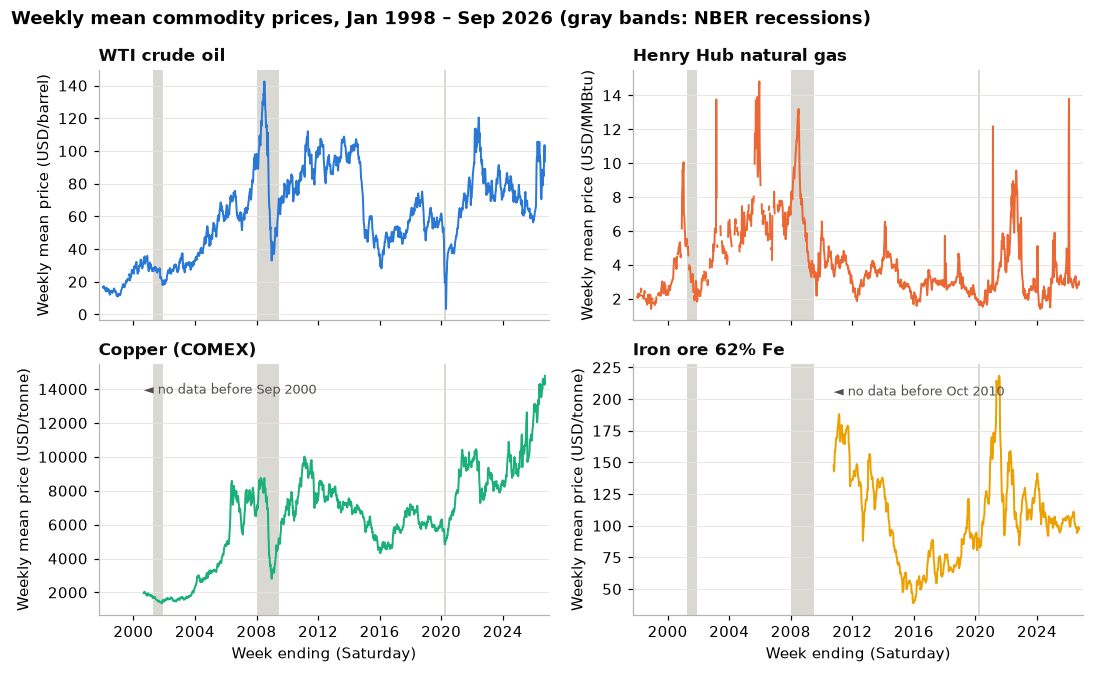

In [18]:
# ---- Figure 2: the predictors, small multiples with each commodity's own unit ---------------
fig, axes = plt.subplots(2, 2, figsize=(10, 6.2), sharex=True)
for ax, k in zip(axes.ravel(), KEYS):
    shade_recessions(ax)
    ax.plot(master.index, master[f"{k}_mean"], color=COLORS[k], lw=1.3)
    ax.set_title(LABELS[k], color=COLORS["claims"], loc="left")
    ax.set_ylabel(f"Weekly mean price ({UNITS[k]})")
    ax.margins(x=0.01); ax.grid(axis="x", visible=False)
    first = master[f"{k}_mean"].first_valid_index()
    if first > pd.Timestamp("1998-12-31"):            # structural gap, not a stray missing week
        ax.text(first, ax.get_ylim()[1] * 0.93, f"◄ no data before {first:%b %Y}", fontsize=8.5, color=COLORS["muted"], ha="left", va="top")
for ax in axes[1]:
    ax.set_xlabel("Week ending (Saturday)")
fig.suptitle("Weekly mean commodity prices, Jan 1998 – Sep 2026 (gray bands: NBER recessions)", x=0.01, ha="left", fontweight="semibold")
fig.tight_layout(); fig.savefig(FIGS / "fig2_commodity_prices.png"); plt.show()

**Figure 2.** Weekly mean prices of the four input commodities, each on its own axis and physical unit:
WTI crude oil (USD per barrel, FRED DCOILWTICO), Henry Hub natural gas (USD per MMBtu, FRED DHHNGSP), COMEX copper
front-month futures converted to USD per metric tonne (Yahoo Finance HG=F), and iron ore 62 % Fe CFR China futures
(USD per metric tonne, Yahoo Finance TIO=F). Copper and iron ore begin when their futures histories begin
(Sep 2000 and Oct 2010); earlier weeks are missing by construction. All four fall sharply inside the 2008–09 and 2020
recessions, which is why the shock–claims relationship must be examined in both directions.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


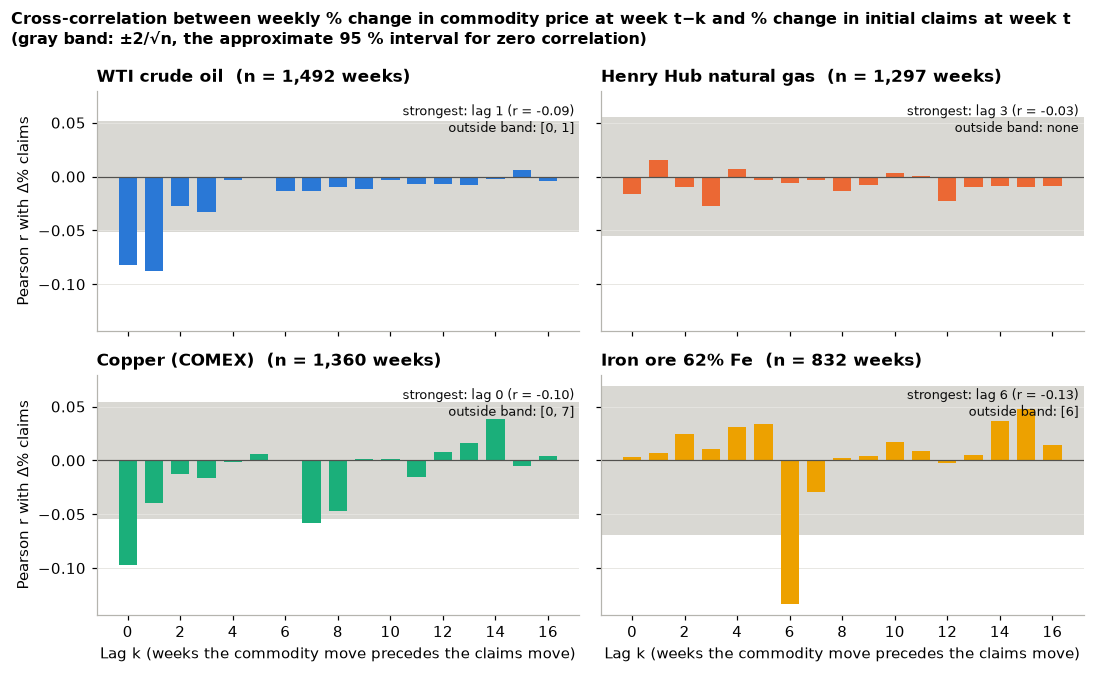

In [19]:
# ---- Figure 3: lag structure --------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 6.2), sharex=True, sharey=True)
lags = xcorr.index.to_numpy()
for ax, k in zip(axes.ravel(), KEYS):
    ax.axhspan(-band[k], band[k], color=COLORS["rec"], zorder=0, lw=0)
    ax.bar(lags, xcorr[k], width=0.7, color=COLORS[k], zorder=2)
    ax.axhline(0, color=COLORS["muted"], lw=0.8)
    j = int(xcorr[k].abs().idxmax())
    outside = [int(l) for l in lags if abs(xcorr[k][l]) > band[k]]
    ax.text(0.99, 0.95, f"strongest: lag {j} (r = {xcorr[k][j]:+.2f})\noutside band: {outside if outside else 'none'}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=COLORS["claims"])
    ax.set_title(f"{LABELS[k]}  (n = {n_eff[k]:,} weeks)", loc="left")
    ax.set_xticks(range(0, 17, 2)); ax.grid(axis="x", visible=False)
for ax in axes[:, 0]:
    ax.set_ylabel("Pearson r with Δ% claims")
for ax in axes[1]:
    ax.set_xlabel("Lag k (weeks the commodity move precedes the claims move)")
fig.suptitle("Cross-correlation between weekly % change in commodity price at week t−k and % change in initial claims at week t\n"
             "(gray band: ±2/√n, the approximate 95 % interval for zero correlation)", x=0.01, ha="left", fontweight="semibold", fontsize=10.5)
fig.tight_layout(); fig.savefig(FIGS / "fig3_lag_crosscorrelation.png"); plt.show()

**Figure 3.** Lead–lag structure between commodity price shocks and claims. Each bar is the Pearson correlation between
the week-over-week percentage change in a commodity's weekly mean price *k* weeks earlier and the week-over-week
percentage change in initial claims; the gray band is ±2/√n. Correlations are small, as expected for noisy weekly
changes, but oil's effect is concentrated at lags 0–1 with a negative sign, copper shows a secondary dip at lags 7–8,
and iron ore's one coefficient outside the band is at lag 6. The figure motivates keeping short (0–2) and medium
(6–8) lags per commodity rather than the full 16-week block.

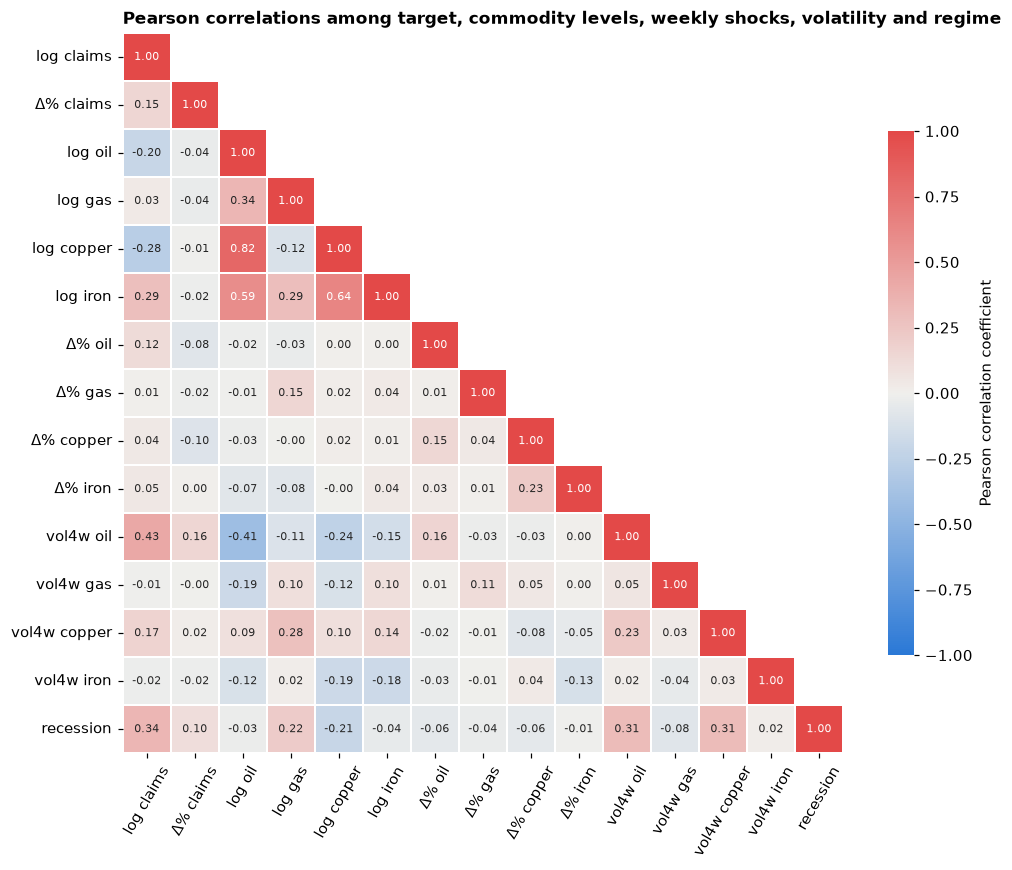

In [20]:
# ---- Figure 4: correlation heatmap (diverging: blue negative, gray zero, red positive) ------
pretty = {"log_icsa": "log claims", "icsa_pct_chg_1w": "Δ% claims", "usrec": "recession"}
for k in KEYS:
    pretty.update({f"{k}_log_mean": f"log {k}", f"{k}_pct_1w": f"Δ% {k}", f"{k}_vol_4w": f"vol4w {k}"})
cm = mpl.colors.LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
fig, ax = plt.subplots(figsize=(9.5, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr.rename(index=pretty, columns=pretty), mask=mask, cmap=cm, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7.5}, linewidths=1, linecolor="white",
            cbar_kws={"label": "Pearson correlation coefficient", "shrink": 0.7}, ax=ax, square=True)
ax.set_title("Pearson correlations among target, commodity levels, weekly shocks, volatility and regime", loc="left")
ax.tick_params(axis="x", rotation=60); ax.grid(False)
fig.tight_layout(); fig.savefig(FIGS / "fig4_correlation_heatmap.png"); plt.show()

**Figure 4.** Lower triangle of the Pearson correlation matrix for the target (log level and weekly % change),
commodity log levels, weekly % changes, trailing 4-week volatilities and the NBER recession flag (pairwise-complete
observations). Diverging scale: blue negative, gray zero, red positive. Levels are strongly inter-correlated
(oil–copper 0.82), so they should not enter a linear model together untransformed; the % change block is nearly
orthogonal, which is desirable for the lagged-shock features.

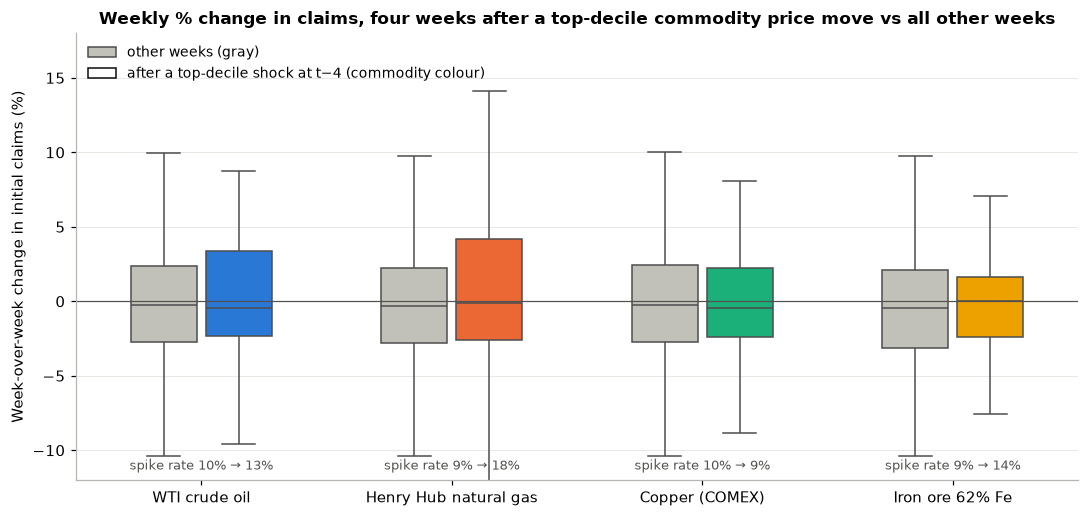

In [21]:
# ---- Figure 5: distribution of claims change after a commodity shock vs otherwise -----------
rows = []
for k in KEYS:
    absmove = master[f"{k}_pct_1w"].abs()
    shock = (absmove >= absmove.quantile(0.90)).astype(float).where(absmove.notna()).shift(LAG_CT)
    tmp = pd.DataFrame({"commodity": LABELS[k], "group": shock.map({1.0: "after a top-decile shock (t−4)", 0.0: "other weeks"}),
                        "dy": master["icsa_pct_chg_1w"]}).dropna()
    rows.append(tmp)
plot_df = pd.concat(rows)
fig, ax = plt.subplots(figsize=(10, 4.8))
order = [LABELS[k] for k in KEYS]
sns.boxplot(data=plot_df, x="commodity", y="dy", hue="group", order=order, hue_order=["other weeks", "after a top-decile shock (t−4)"],
            palette={"other weeks": "#c3c2b7", "after a top-decile shock (t−4)": "#2a78d6"}, width=0.6, gap=0.12,
            showfliers=False, linewidth=1, ax=ax)
# recolour the shock boxes with each commodity's own hue so identity follows the entity
shock_patches = [p for p in ax.patches if isinstance(p, mpl.patches.PathPatch)][len(order):]
for p, k in zip(shock_patches, KEYS):
    p.set_facecolor(COLORS[k])
ax.axhline(0, color=COLORS["muted"], lw=0.8)
ax.set_ylim(-12, 18)
ax.set_ylabel("Week-over-week change in initial claims (%)"); ax.set_xlabel("")
ax.set_title("Weekly % change in claims, four weeks after a top-decile commodity price move vs all other weeks")
handles, labels_ = ax.get_legend_handles_labels()
handles[1] = mpl.patches.Patch(facecolor="white", edgecolor=COLORS["claims"], label=labels_[1])
ax.legend(handles, ["other weeks (gray)", "after a top-decile shock at t−4 (commodity colour)"], loc="upper left", fontsize=9)
ax.grid(axis="x", visible=False)
# direct label: spike share per group under each pair
for i, k in enumerate(KEYS):
    r = contingency.loc[contingency["commodity"] == LABELS[k]].iloc[0]
    ax.text(i, -11.3, f"spike rate {r['spike rate otherwise']*100:.0f}% → {r['spike rate after shock']*100:.0f}%",
            ha="center", fontsize=8.5, color=COLORS["muted"])
fig.tight_layout(); fig.savefig(FIGS / "fig5_claims_change_after_shock.png"); plt.show()

**Figure 5.** Distribution (median, interquartile box, 1.5×IQR whiskers; outliers beyond ±12/18 % hidden for legibility,
not removed from the statistics) of the week-over-week percentage change in initial claims, split by whether the
commodity recorded a top-decile absolute weekly price move four weeks earlier. Gray boxes are all other weeks;
coloured boxes follow a shock. Text under each pair gives the share of weeks that are claims *spikes* (top-decile
rises, > 5.2 %). Natural-gas shocks double the spike rate (9 % → 18 %), the clearest bivariate pattern in the data;
the other commodities show wider dispersion after shocks but little shift in the centre.

# **Section 4: Formal Hypothesis Framing & Analytical Plan**

Notation: $Y_t$ is the weekly change in log initial claims, $\Delta \log(\text{ICSA}_t)$ (equivalently the weekly
% change); $\Delta p^{c}_{t-k}$ is the % change in commodity $c$'s weekly mean price $k$ weeks earlier;
$\sigma^{c}_{t}$ is its trailing 4-week volatility; $R_t$ is the NBER recession flag.

**H1 — Energy shocks (crude oil).**
$H_0: \beta^{oil}_k = 0 \;\; \forall k \in \{0,\dots,16\}$ versus
$H_1: \beta^{oil}_k \neq 0$ for at least one $k$, in $Y_t = \alpha + \sum_k \beta^{oil}_k \Delta p^{oil}_{t-k} + \gamma' Z_t + \varepsilon_t$.
The EDA suggests $\beta^{oil}_{0,1} < 0$ (price collapses, not spikes, precede claims rises), so the test is two-sided.

**H2 — Energy shocks (natural gas).**
$H_0: \beta^{gas}_k = 0 \;\; \forall k$ versus $H_1: \beta^{gas}_k > 0$ for some $k \in \{2,\dots,8\}$.
Motivated by the contingency result (gas shock at $t-4$ doubles the spike probability).

**H3 — Industrial-metal shocks (copper and iron ore).**
$H_0: \beta^{cu}_k = \beta^{fe}_k = 0 \;\; \forall k$ versus $H_1$: at least one differs from zero.
Given the "Dr. Copper" pattern we expect *negative* coefficients (falling metal prices signal shrinking orders and
subsequent layoffs); the direction will be reported, not assumed.

**H4 — Volatility, not only direction.**
$H_0: \delta^{c} = 0$ versus $H_1: \delta^{c} > 0$ in $Y_t = \alpha + \delta^{c}\sigma^{c}_{t-4} + \gamma' Z_t + \varepsilon_t$,
for each commodity $c$: uncertainty about input costs raises layoffs independently of the sign of the price move.

**H5 — Lag structure and regime dependence.**
$H_0$: the lag $k^{*}$ at which $|\beta^{c}_{k}|$ is maximal is the same in recession and expansion weeks, and the
interaction $\beta^{c}_{k} \cdot R_t$ is zero; $H_1$: the transmission is faster and/or stronger in recessions
($\theta^{c}_{k} \neq 0$ in $Y_t = \alpha + \beta^{c}_{k}\Delta p^{c}_{t-k} + \theta^{c}_{k}\,\Delta p^{c}_{t-k} R_t + \lambda R_t + \gamma' Z_t + \varepsilon_t$).
The proposal's expectation is $k^{*} \in [4, 12]$ weeks.

**Analytical plan.** H1–H3 will be tested with distributed-lag regressions on $\Delta\log$ claims with Newey–West
(HAC) standard errors, complemented by Granger-causality F-tests; H4 adds volatility terms; H5 adds the recession
interaction and a rolling-window re-estimation. The predictive counterpart is a gradient-boosted regressor on the
same features with time-series cross-validation, from which the strongest lags per commodity will be read off
(permutation importance) and kept for the final, parsimonious model. All scalers and thresholds will be refitted
on the training window only.

In [22]:
# Variable mapping: every hypothesis -> concrete columns in master_weekly.csv
controls = "usrec, covid_period, lagged target (icsa_pct_chg_1w shifted 1–2)"
mapping = pd.DataFrame([
    ["H1", "icsa_pct_chg_1w  (alt.: Δ log_icsa; icsa_spike for classification, derived in the notebook)",
     "oil_pct_1w (lag 0) + oil_pct_lag1..16 from add_lags()", controls + ", gas_pct_lag*"],
    ["H2", "icsa_pct_chg_1w / icsa_spike", "gas_pct_lag2..8", controls + ", oil_pct_lag*"],
    ["H3", "icsa_pct_chg_1w / icsa_spike", "copper_pct_1w, iron_pct_1w + their lag1..16 from add_lags()", controls + ", oil_pct_lag*"],
    ["H4", "icsa_pct_chg_1w", "oil_vol_4w, gas_vol_4w, copper_vol_4w, iron_vol_4w (each shifted 4 weeks)", controls + ", own {c}_pct_lag4"],
    ["H5", "icsa_pct_chg_1w", "{c}_pct_lagk × usrec (interaction) for the k* found under H1–H3", controls],
], columns=["Hypothesis", "Target / response (Y)", "Primary explanatory predictors (X)", "Confounders / controls (Z)"])
mapping.to_csv(TABLES / "t16_hypothesis_variable_mapping.csv", index=False)
display(mapping.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"}))

Hypothesis,Target / response (Y),Primary explanatory predictors (X),Confounders / controls (Z)
H1,"icsa_pct_chg_1w (alt.: Δ log_icsa; icsa_spike for classification, derived in the notebook)",oil_pct_1w (lag 0) + oil_pct_lag1..16 from add_lags(),"usrec, covid_period, lagged target (icsa_pct_chg_1w shifted 1–2), gas_pct_lag*"
H2,icsa_pct_chg_1w / icsa_spike,gas_pct_lag2..8,"usrec, covid_period, lagged target (icsa_pct_chg_1w shifted 1–2), oil_pct_lag*"
H3,icsa_pct_chg_1w / icsa_spike,"copper_pct_1w, iron_pct_1w + their lag1..16 from add_lags()","usrec, covid_period, lagged target (icsa_pct_chg_1w shifted 1–2), oil_pct_lag*"
H4,icsa_pct_chg_1w,"oil_vol_4w, gas_vol_4w, copper_vol_4w, iron_vol_4w (each shifted 4 weeks)","usrec, covid_period, lagged target (icsa_pct_chg_1w shifted 1–2), own {c}_pct_lag4"
H5,icsa_pct_chg_1w,{c}_pct_lagk × usrec (interaction) for the k* found under H1–H3,"usrec, covid_period, lagged target (icsa_pct_chg_1w shifted 1–2)"


# **Section 5: Progressive Manuscript Workflow**
The accompanying PDF, *Milestone02_Report.pdf*, is written as Draft Section II (Data and Preprocessing) and Draft
Section III (Exploratory Data Analysis) of the final manuscript, with the hypotheses of Section 4 above as the
bridge into the modelling sections. All numbers in the PDF are read from the CSV tables in `data/processed/tables/`
and the figures in `figures/`, both produced by this notebook.

In [23]:
# Export the data dictionary and list every artefact produced by this notebook
data_dictionary(master).to_csv(ROOT / "data" / "processed" / "data_dictionary.csv", index=False)
print("Tables:"); print("\n".join(f"  {p.name}" for p in sorted(TABLES.glob("*.csv"))))
print("Figures:"); print("\n".join(f"  {p.name}" for p in sorted(FIGS.glob("*.png"))))

Tables:
  t01_master_overview.csv
  t02_sources.csv
  t03_missing_all_columns.csv
  t04_missing_by_year.csv
  t05_log_transform_skew.csv
  t06_scaling_summary.csv
  t07_dummy_counts.csv
  t08_univariate.csv
  t09_resistant_vs_nonresistant.csv
  t10_outlier_audit.csv
  t11_correlation_matrix.csv
  t12_cross_correlation_lags.csv
  t13_xcorr_best_lag.csv
  t14_groupby_regime.csv
  t15_contingency_shock_spike.csv
  t16_hypothesis_variable_mapping.csv
Figures:
  fig1_claims_timeseries.png
  fig2_commodity_prices.png
  fig3_lag_crosscorrelation.png
  fig4_correlation_heatmap.png
  fig5_claims_change_after_shock.png
